<a href="https://colab.research.google.com/github/Sadeemalj6/CV_Day1_Lab_Student.ipynb/blob/main/CV_Day1_Lab_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#15294D;padding:24px 32px;border-radius:12px;margin-bottom:8px">
<h1 style="color:white;margin:0;font-family:Arial;font-size:26px">Your First CV App</h1>
<p style="color:#6FAF22;margin:8px 0 4px 0;font-size:15px;font-family:Arial;font-weight:bold">Computer Vision Bootcamp | Day 1 | Hands-on Lab</p>
<p style="color:#A0C4FF;margin:0;font-size:13px;font-family:Arial">Saudi Digital Academy x atomcamp Arabia</p>
</div>

<div style="background:#F0FDF4;border-left:5px solid #6FAF22;padding:14px 18px;border-radius:6px;margin:12px 0">
<b style="color:#15294D">Goal:</b> build a mini Computer Vision app that takes one image of Masjid Al-Haram and processes it with everything you learned today.<br><br>
<b style="color:#15294D">The full pipeline you will build:</b>
<pre style="background:white;padding:10px;border-radius:6px;margin:8px 0">
Load Image  &rarr;  Grayscale  &rarr;  Edges  &rarr;  Preprocess  &rarr;  Augment  &rarr;  CNN Preview
 (Step 1)        (Part 1)       (Part 1)     (Part 1)        (Part 1)       (Part 2)
</pre>
<b style="color:#6FAF22">Part 1 (Today):</b> apply the CV techniques you already know.<br>
<b style="color:#0D9488">Part 2 (Preview):</b> watch a CNN recognise objects in the same image. You will learn how it works tomorrow.
</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:12px 0">
<b>How this lab works:</b> cells marked <code>TODO</code> have a blank <code>___</code>. Replace it with your code, then run the cell.<br>
We solve the first ones together. The hints get shorter as you go.<br>
If a cell shows an error, read the last line of the error first: it usually tells you exactly what is wrong.
</div>

---
## Step 0: Setup

The cell below imports everything this notebook uses, in one place (Google Colab already has all these libraries installed). Read the comment above each import: what the library is, where it is used in general, and where we use it in this notebook.

**What you will see:** a short message with the versions of OpenCV, NumPy and PyTorch. If you see an error instead, run the cell again.

In [2]:
# ============================================================================
#  LIBRARIES USED IN THIS NOTEBOOK
# ============================================================================

# os : Python built-in module for files and folders.
#      In general  : build paths, list a folder, check if a file exists.
#      In this lab : Step 1, to find the image you uploaded into the Colab Files panel.
import os

# numpy (np) : the core library for numerical arrays in Python.
#      In general  : every image in Python is a NumPy array of numbers (H x W x Channels).
#      In this lab : all Parts. Shapes, pixel math, noise, normalization.
import numpy as np

# cv2 (OpenCV) : the most widely used Computer Vision library.
#      In general  : read/resize/convert images, filters, edge detection, geometry.
#      In this lab : Part 1. Grayscale, Canny edges, resize, and most augmentations.
import cv2

# matplotlib.pyplot (plt) : the standard plotting library.
#      In general  : charts and displaying images inside a notebook.
#      In this lab : every step, to show images side by side.
import matplotlib.pyplot as plt

# PIL (Pillow) : the standard Python library for opening image files.
#      In general  : open JPG/PNG/WEBP, fix phone rotation (EXIF), convert colour modes.
#      In this lab : Step 1 to load your image safely; Part 2 because torchvision expects PIL images.
from PIL import Image, ImageOps, UnidentifiedImageError

# skimage.data (scikit-image) : ships a few built-in sample images.
#      In general  : scikit-image is a classic image-processing library.
#      In this lab : Step 1 ONLY as a backup image if your upload does not work.
from skimage import data as sk_data

# torch (PyTorch) : a deep learning framework (tensors + neural networks).
#      In general  : train and run neural networks such as CNNs.
#      In this lab : Part 2, to run the pre-trained CNN.
import torch

# torchvision : PyTorch's Computer Vision add-on.
#      In general  : ready-made models, datasets and image transforms.
#      In this lab : Part 1 (random augmentation pipeline) and Part 2 (MobileNetV2 model).
import torchvision.transforms as T
from torchvision import models

print('All libraries imported.')
print(f'OpenCV {cv2.__version__} | NumPy {np.__version__} | PyTorch {torch.__version__}')

All libraries imported.
OpenCV 4.14.0 | NumPy 2.1.3 | PyTorch 2.11.0+cpu


---
## Step 1: Load Your Image

<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: <b style='color:#6FAF22'>[ Load Image ]</b> &rarr; Grayscale &rarr; Edges &rarr; Preprocess &rarr; Augment &rarr; CNN Preview</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin-top:10px">
<b>Goal of this step:</b> bring one image into the notebook. Every step after this works on it.<br><br>
<b>First, get an image:</b> search Google Images for <b>Masjid Al-Haram Makkah</b> and save one image to your device.<br><br>
<b>Option 1 (the cell below): your own image.</b> Run the cell and click <b>Choose Files</b>.<br>
If the button shows an error (for example <code>RangeError: Maximum call stack size exceeded</code>, common in Safari), nothing is broken: open the notebook in <b>Chrome</b> and try again, or use Option 2.<br><br>
<b>Option 2 (the next cell): our default image.</b> Use it only if Option 1 did not work. Run <b>one</b> option, not both.<br><br>
<b>Accepted formats:</b> JPG, JPEG, PNG, WEBP. <b>Not accepted:</b> PDF, Word, HEIC (iPhone photo format). On iPhone, take a screenshot of the image instead; that gives you a PNG.<br><br>
<b>What you will see:</b> your image, and one line with its size before and after resizing. We resize it to 640 pixels wide and keep its shape (no stretching).
</div>

Saving images.jpg to images.jpg


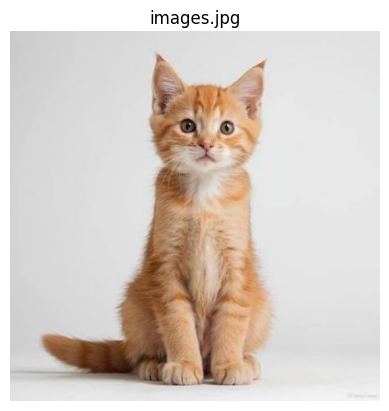

447 x 447  ->  640 x 640  |  shape (640, 640, 3)  |  1,228,800 numbers


In [3]:
# Option 1: upload an image from your device
from google.colab import files                   # Colab's "Choose Files" upload button

source = next(iter(files.upload()))              # click "Choose Files"; we keep the file name

with Image.open(source) as im:                   # open the image file
    img_original = np.array(ImageOps.exif_transpose(im).convert('RGB'))   # fix phone rotation, force RGB, convert to a NumPy array

# Resize to 640 pixels wide, keeping the original shape (no stretching)
h0, w0  = img_original.shape[:2]                 # original height and width
img_rgb = cv2.resize(img_original, (640, round(h0 * 640 / w0)), interpolation=cv2.INTER_AREA)
H, W, C = img_rgb.shape                          # Height, Width, Channels; used in later steps

plt.imshow(img_rgb); plt.title(source); plt.axis('off'); plt.show()
print(f'{w0} x {h0}  ->  {W} x {H}  |  shape {img_rgb.shape}  |  {img_rgb.size:,} numbers')

**Option 2: the default image.** Run this cell only if Option 1 did not work. It loads a ready image that comes with the scikit-image library, so the rest of the lab still works.<br>
**What you will see:** the default image and its size, exactly like Option 1. Then continue to Part 1.

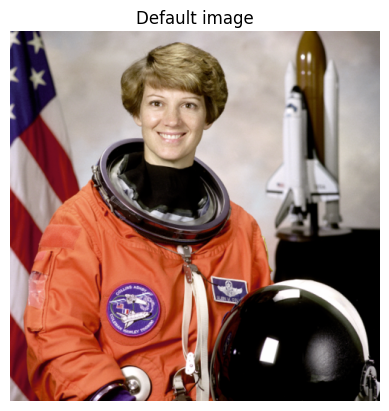

512 x 512  ->  640 x 640  |  shape (640, 640, 3)  |  1,228,800 numbers


In [3]:
# Option 2: the default image (use it if Option 1 did not work)
img_original = sk_data.astronaut()               # a ready sample image inside scikit-image, already a NumPy RGB array (512 x 512 x 3)
source = 'Default image'                         # name shown as the image title

# Same resize and display as Option 1
h0, w0  = img_original.shape[:2]                 # original height and width
img_rgb = cv2.resize(img_original, (640, round(h0 * 640 / w0)), interpolation=cv2.INTER_AREA)  # 640 wide, keep aspect ratio
H, W, C = img_rgb.shape                          # Height, Width, Channels; used in later steps
plt.imshow(img_rgb); plt.title(source); plt.axis('off'); plt.show()
print(f'{w0} x {h0}  ->  {W} x {H}  |  shape {img_rgb.shape}  |  {img_rgb.size:,} numbers')

---
# PART 1: What You Learned Today

<div style="background:#F0FDF4;border-left:5px solid #6FAF22;padding:12px 16px;border-radius:6px">
Four techniques, applied in order. The output of each one is the input of the next.<br>
<b>Grayscale</b> (simplify the colours) &rarr; <b>Edges</b> (find shapes) &rarr; <b>Preprocess</b> (make it model-ready) &rarr; <b>Augment</b> (create training variety)
</div>

### Technique 1: Grayscale Conversion

<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Load Image &rarr; <b style='color:#6FAF22'>[ Grayscale ]</b> &rarr; Edges &rarr; Preprocess &rarr; Augment &rarr; CNN Preview</div>

**Why:** many tasks (edges, shapes) do not need colour. Removing it makes the image 3x smaller and simpler.<br>
**Input:** RGB image, 3 channels. **Output:** one channel, each pixel is a brightness value from 0 (black) to 255 (white).

**What you will see:** your image next to its grayscale version, and how many numbers each one needs. Notice the shape changes from (H, W, 3) to (H, W).

<div style='background:#FFF7ED;border-left:5px solid #E8A020;padding:8px 14px;border-radius:6px'><b>Predict before you run:</b> the RGB image has H x W x 3 numbers. How many numbers will the grayscale image have?</div>

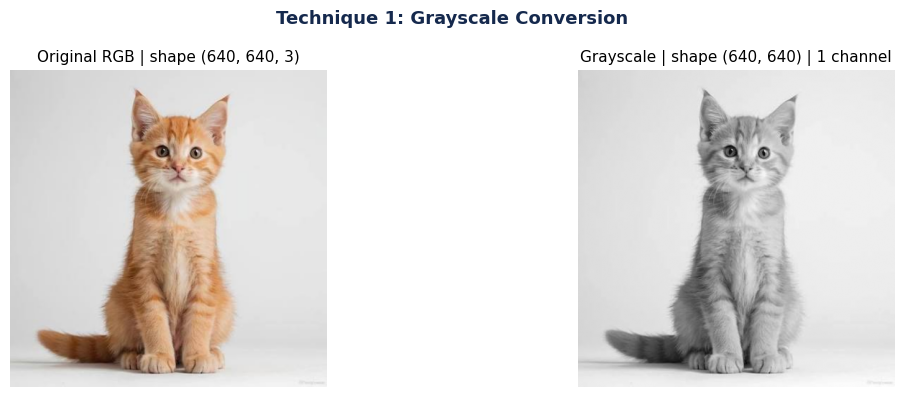

RGB  : 1,228,800 numbers
Gray : 409,600 numbers  (3x fewer)


In [4]:
# TODO 1: convert img_rgb to grayscale (1 number per pixel, 0 = black ... 255 = white)
# Hint: cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) # TODO 1

# Show the two images side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))           # 1 row, 2 columns
axes[0].imshow(img_rgb)
axes[0].set_title(f'Original RGB | shape {img_rgb.shape}', fontsize=11)
axes[1].imshow(img_gray, cmap='gray')                     # cmap='gray': draw 1-channel values as shades of gray
axes[1].set_title(f'Grayscale | shape {img_gray.shape} | 1 channel', fontsize=11)
for ax in axes: ax.axis('off')                            # hide the axis numbers
plt.suptitle('Technique 1: Grayscale Conversion', fontsize=13, color='#15294D', fontweight='bold')
plt.tight_layout(); plt.show()

# Compare how many numbers each version needs
print(f'RGB  : {img_rgb.size:,} numbers')
print(f'Gray : {img_gray.size:,} numbers  (3x fewer)')

### Technique 2: Edge Detection (Canny)

<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Load Image &rarr; Grayscale &rarr; <b style='color:#6FAF22'>[ Edges ]</b> &rarr; Preprocess &rarr; Augment &rarr; CNN Preview</div>

**Why:** edges are where brightness changes sharply: outlines of minarets, arches, the Kaaba, people.<br>
**Input:** the grayscale image from Technique 1. **Output:** a black image with white pixels on the edges.<br>
We blur slightly first so small noise does not become fake edges.

**What you will see:** the grayscale image next to its edges, and how many edge pixels were found.<br>**Try it:** change `threshold1` and `threshold2` and run again. Lower values give more edges.

<div style='background:#FFF7ED;border-left:5px solid #E8A020;padding:8px 14px;border-radius:6px'><b>Predict before you run:</b> if you lower <code>threshold1</code> from 80 to 30, will you get more edges or fewer?</div>

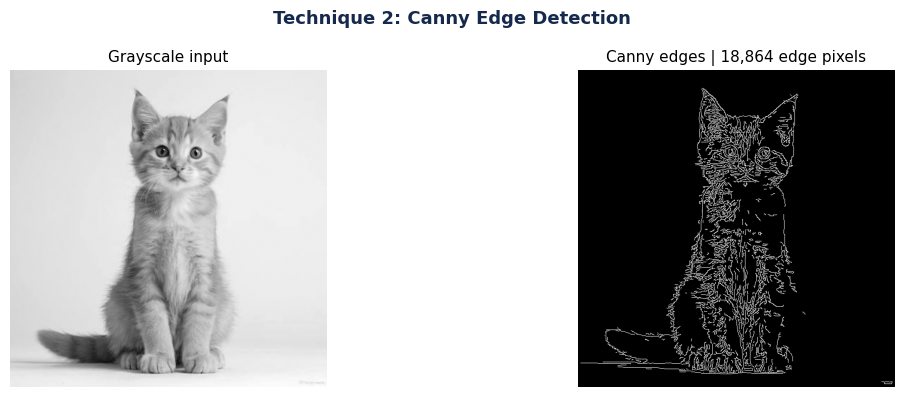

Try it: change threshold1 / threshold2 and re-run. Lower values = more edges.


In [5]:
# TODO 2: blur img_gray a little so tiny noise does not become fake edges. Use a 5 x 5 window.
# Hint: cv2.GaussianBlur(image, (width, height), 0)
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)  # TODO 2

# TODO 3: find the edges in blurred with Canny, threshold1 = 80, threshold2 = 180
# Hint: cv2.Canny(image, threshold1, threshold2)
# A pixel is an edge if the brightness change there is strong:
#   change > threshold2  -> strong edge, kept
#   change < threshold1  -> not an edge, removed
#   in between           -> kept only if connected to a strong edge
edges = cv2.Canny(img_gray, threshold1 = 50, threshold2 = 80)  # TODO 3

# Show grayscale input next to the edges
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Grayscale input', fontsize=11)
axes[1].imshow(edges, cmap='gray')
axes[1].set_title(f'Canny edges | {np.count_nonzero(edges):,} edge pixels', fontsize=11)   # count_nonzero = number of white (edge) pixels
for ax in axes: ax.axis('off')
plt.suptitle('Technique 2: Canny Edge Detection', fontsize=13, color='#15294D', fontweight='bold')
plt.tight_layout(); plt.show()

print('Try it: change threshold1 / threshold2 and re-run. Lower values = more edges.')

### Technique 3: Preprocessing (Resize + Normalize)

<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Load Image &rarr; Grayscale &rarr; Edges &rarr; <b style='color:#6FAF22'>[ Preprocess ]</b> &rarr; Augment &rarr; CNN Preview</div>

**Why:** a CNN only accepts inputs of a fixed size and a fixed number range.<br>
**Steps:** (1) resize to **224 x 224**, the size MobileNetV2 expects &rarr; (2) scale pixels from **0..255** to **0..1** &rarr; (3) standardize each colour channel using the ImageNet mean and std, the same numbers the model saw during training.<br>
**Input:** the colour image. **Output:** a 224 x 224 x 3 array of small numbers centred around 0.

**What you will see:** the original next to the 224 x 224 version, a chart of pixel values before and after standardizing, and the value ranges printed under it. Notice the 224 x 224 image looks slightly stretched.

<div style='background:#FFF7ED;border-left:5px solid #E8A020;padding:8px 14px;border-radius:6px'><b>Predict before you run:</b> after dividing by 255, what will the smallest and largest pixel values be?</div>

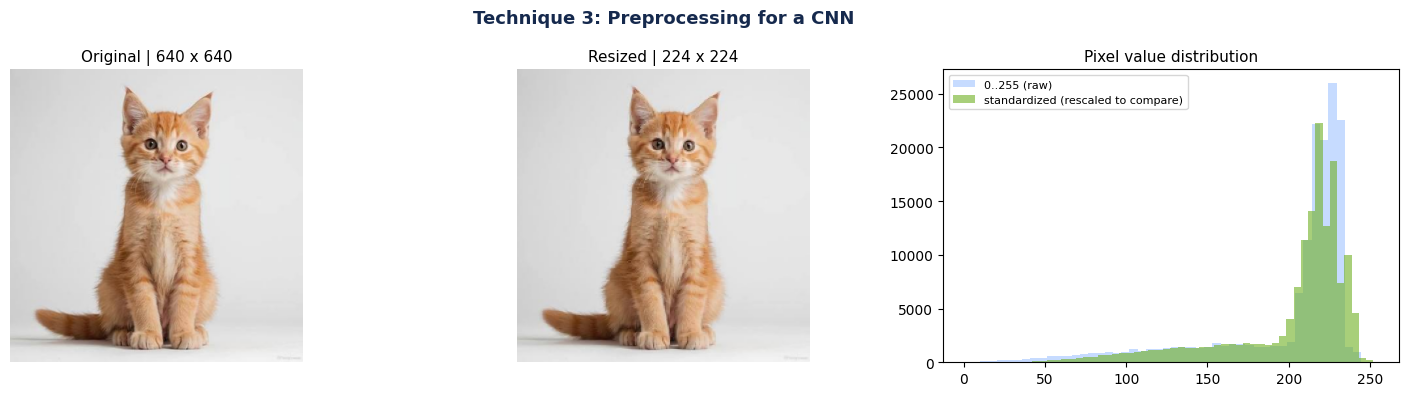

Raw pixels     : 0 .. 255
Scaled 0..1    : 0.00 .. 1.00
Standardized   : -1.98 .. 2.48   (mean = 1.48)
Final shape    : (224, 224, 3)  ->  150,528 numbers go into the CNN


In [6]:
# Average and spread of each colour (R, G, B) over the 1.2 million ImageNet training images
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

# TODO 4: resize img_rgb to 224 x 224 (the size the model expects)
# Hint: cv2.resize
img_224 = cv2.resize(img_rgb,(224,224))  # TODO 4

# TODO 5: scale the pixels of img_224 from 0..255 to 0..1
# Hint: convert to float32 first, then divide by the largest possible pixel value
img_01 = img_224.astype(np.float32)/255.0  # TODO 5

# TODO 6: standardize img_01: subtract IMAGENET_MEAN, then divide by IMAGENET_STD
img_standard = (img_01 - IMAGENET_MEAN)/IMAGENET_STD  # TODO 6

# Left: original, middle: 224 x 224, right: histogram (how many pixels have each value)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_rgb);  axes[0].set_title(f'Original | {W} x {H}', fontsize=11); axes[0].axis('off')
axes[1].imshow(img_224);  axes[1].set_title('Resized | 224 x 224', fontsize=11);   axes[1].axis('off')
axes[2].hist(img_224.ravel(), bins=50, alpha=0.6, label='0..255 (raw)', color='#A0C4FF')
axes[2].hist(img_standard.ravel() * 50 + 128, bins=50, alpha=0.6, label='standardized (rescaled to compare)', color='#6FAF22')
axes[2].set_title('Pixel value distribution', fontsize=11); axes[2].legend(fontsize=8)
plt.suptitle('Technique 3: Preprocessing for a CNN', fontsize=13, color='#15294D', fontweight='bold')
plt.tight_layout(); plt.show()

# Print the value range after each step
print(f'Raw pixels     : {img_224.min()} .. {img_224.max()}')
print(f'Scaled 0..1    : {img_01.min():.2f} .. {img_01.max():.2f}')
print(f'Standardized   : {img_standard.min():.2f} .. {img_standard.max():.2f}   (mean = {img_standard.mean():.2f})')
print(f'Final shape    : {img_standard.shape}  ->  {img_standard.size:,} numbers go into the CNN')

### Technique 4: Data Augmentation

<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Load Image &rarr; Grayscale &rarr; Edges &rarr; Preprocess &rarr; <b style='color:#6FAF22'>[ Augment ]</b> &rarr; CNN Preview</div>

<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:14px 18px;border-radius:6px">
<b>The problem:</b> a model trained on few images memorises them (overfitting). It fails on a photo taken from another angle, at night, or with people in front.<br><br>
<b>The idea:</b> create new, realistic versions of the same image by changing it slightly. The label does not change: a rotated photo of the Haram is still the Haram.<br><br>
<b>The rules:</b><br>
1. Use it <b>during training only</b>. Never augment test images or real predictions.<br>
2. The change must be <b>realistic</b> for your data. Horizontal flip is fine for the Haram; vertical flip is not (nobody photographs it upside down). For Arabic text or digits, even horizontal flip is wrong because it changes the meaning.
</div>

#### The 4 families of augmentation

| Family | Technique | What it simulates in real life |
|---|---|---|
| **A. Geometric** (moves pixels) | 1. Horizontal Flip | Photo taken from the mirror side |
| | 2. Rotation | Camera held at a slight angle |
| | 3. Crop and Zoom | Photo taken closer, or object partly in frame |
| **B. Photometric** (changes colour values) | 4. Brightness | Morning sun vs evening |
| | 5. Contrast | Hazy day vs sharp day |
| | 6. Saturation | Different phone cameras and filters |
| **C. Noise and Blur** (changes quality) | 7. Gaussian Noise | Low light, cheap sensor |
| | 8. Gaussian Blur | Shaky hand, out of focus |
| **D. Occlusion** (hides part) | 9. Cutout | A person or pillar blocking part of the view |

**Plan:** apply each technique on its own (one cell each, compared with the original), then print all of them side by side at the end.

**Setup for augmentation (run once).** This cell creates `show_pair()`, a small function that shows the original next to an augmented version and saves the result for the final gallery. Nothing is displayed except a "Ready" message.

In [7]:
# Helpers for the augmentation section
augmented = {}                        # stores every result: {'technique name': image}; used by the final gallery
rng = np.random.default_rng(seed=42)  # random number generator with a fixed seed, so everyone gets the same random result

def show_pair(aug_img, title, note=''):
    # Show the original next to one augmented version, and save the result.
    augmented[title] = aug_img                                   # save for the gallery at the end
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))            # 1 row, 2 images
    axes[0].imshow(img_rgb);  axes[0].set_title('Original', fontsize=11)
    axes[1].imshow(aug_img);  axes[1].set_title(title, fontsize=11, color='#15294D', fontweight='bold')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()
    if note: print(note)                                         # optional explanation under the images

print('Ready. Run the 9 technique cells below in order.')

Ready. Run the 9 technique cells below in order.


#### Family A. Geometric

**1. Horizontal Flip**: Mirror the image left to right. Every pixel moves; colours stay the same.

**Look for:** objects that were on the left are now on the right.

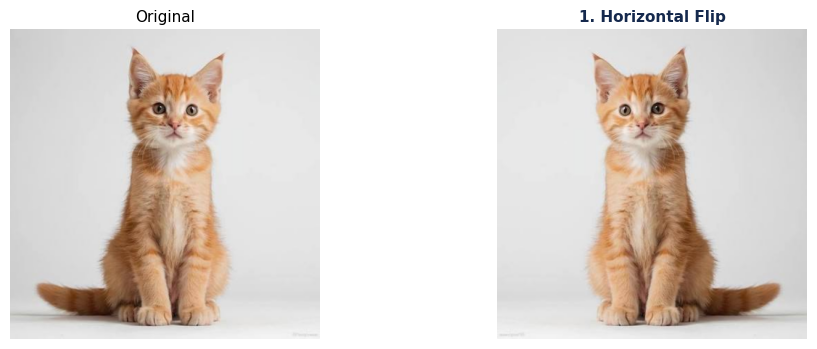

Left and right are swapped. Still clearly the Haram.


In [36]:
# TODO 7: flip img_rgb horizontally (left <-> right)
# Hint: cv2.flip(image, flipCode). Try flipCode 0 and 1: which one is horizontal?
aug_img = cv2.flip(img_rgb, 1) # TODO 7
show_pair(aug_img, '1. Horizontal Flip', 'Left and right are swapped. Still clearly the Haram.')

**2. Rotation**: Rotate around the centre by a small angle. The empty corners are filled by reflecting nearby pixels.

**Look for:** the image is tilted, and the corners are filled with mirrored pixels instead of black.

<div style='background:#FFF7ED;border-left:5px solid #E8A020;padding:8px 14px;border-radius:6px'><b>Predict before you run:</b> rotating a rectangle leaves empty corners. What should we fill them with?</div>

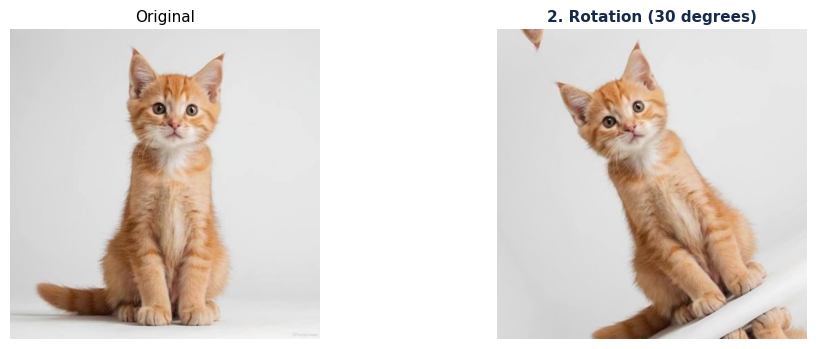

Large angles (e.g. 90) would create unrealistic images.


In [8]:
# TODO 8: choose a small rotation angle in degrees (between 5 and 20)
angle = 30 # TODO 8
matrix = cv2.getRotationMatrix2D((W / 2, H / 2), angle, 1.0)   # 2x3 matrix: rotate around the centre, scale 1.0 (no zoom)
aug_img = cv2.warpAffine(img_rgb, matrix, (W, H), borderMode=cv2.BORDER_REFLECT_101)  # empty corners filled by mirroring nearby pixels
show_pair(aug_img, f'2. Rotation ({angle} degrees)', 'Large angles (e.g. 90) would create unrealistic images.')

**3. Crop and Zoom**: Cut a smaller region and resize it back to full size. The model learns to recognise the scene from a part of it.

**Look for:** the image looks closer, and the edges of the scene are gone.

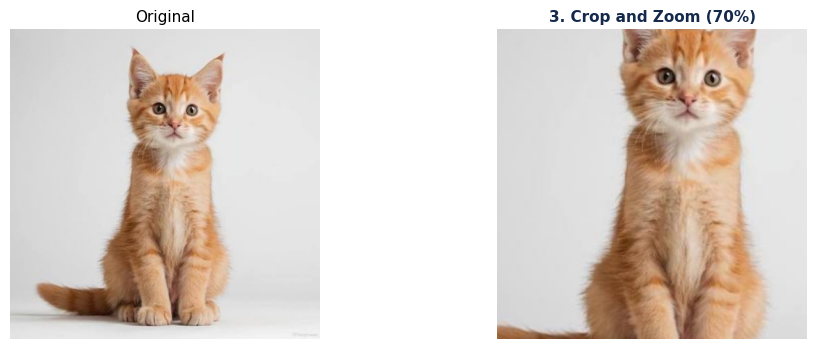

Cropped region: 448 x 448, resized back to 640 x 640.


In [9]:
crop_ratio = 0.7                                          # keep 70% of width and height
ch, cw = int(H * crop_ratio), int(W * crop_ratio)         # crop height and crop width in pixels
y0, x0 = (H - ch) // 2, (W - cw) // 3                     # top-left corner of the crop

# TODO 9: cut the region from row y0 to y0 + ch and column x0 to x0 + cw
# Hint: an image is an array, so slicing works: image[row_start:row_end, col_start:col_end]
crop = img_rgb[y0:y0+ch, x0:x0+cw]  # TODO 9

aug_img = cv2.resize(crop, (W, H), interpolation=cv2.INTER_LINEAR)   # stretch the crop back to full size = "zoom in"
show_pair(aug_img, '3. Crop and Zoom (70%)', f'Cropped region: {cw} x {ch}, resized back to {W} x {H}.')

#### Family B. Photometric

**4. Brightness**: Add the same value to every pixel. Pixels stay in the same place; only their values change.

**Look for:** the whole image is lighter. Very bright areas may turn fully white (they hit 255).

<div style='background:#FFF7ED;border-left:5px solid #E8A020;padding:8px 14px;border-radius:6px'><b>Predict before you run:</b> a pixel with value 250 gets +60. In a <code>uint8</code> array (0 to 255), what happens if we do not protect it?</div>

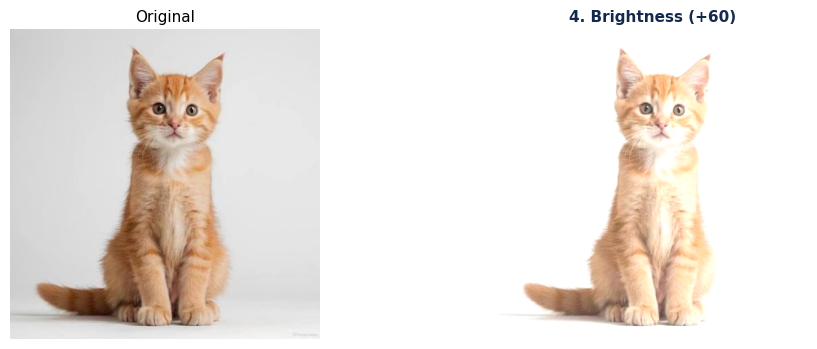

np.clip keeps values inside 0..255 (no overflow).


In [11]:
delta = 60                                                # positive = brighter, negative = darker

# TODO 10: add delta to every pixel of img_rgb
# Steps: (1) convert to int16 so 250 + 60 does not wrap around, (2) add delta,
#        (3) np.clip to keep values inside 0..255, (4) convert back to uint8
aug_img = np.clip(img_rgb.astype(np.int16) + delta, 0, 255).astype(np.uint8)  # TODO 10
show_pair(aug_img, '4. Brightness (+60)', 'np.clip keeps values inside 0..255 (no overflow).')

**5. Contrast**: Stretch pixel values away from the average. Darks get darker, brights get brighter.

**Look for:** shadows are darker and bright areas are brighter, but the average brightness stays the same.

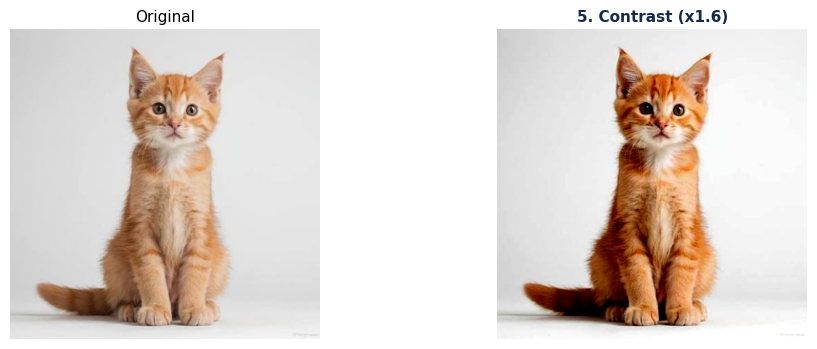

Average brightness kept at 200; the spread around it changed.


In [12]:
factor = 1.6                                              # >1 more contrast, <1 less contrast
mean   = img_rgb.mean()                                   # average brightness of the whole image

# TODO 11: move every pixel away from the average:  new = (pixel - mean) x factor + mean
# Then clip to 0..255 and convert back to uint8, like TODO 10 (use float32 this time)
aug_img = np.clip((img_rgb.astype(np.float32)- mean) * factor + mean,0,255).astype(np.uint8)  # TODO 11
show_pair(aug_img, '5. Contrast (x1.6)', f'Average brightness kept at {mean:.0f}; the spread around it changed.')

**6. Saturation**: Make colours more vivid or more washed out. We switch to HSV colour space, where S is saturation.

**Look for:** colours are stronger. Gray and white areas barely change because they have almost no saturation.

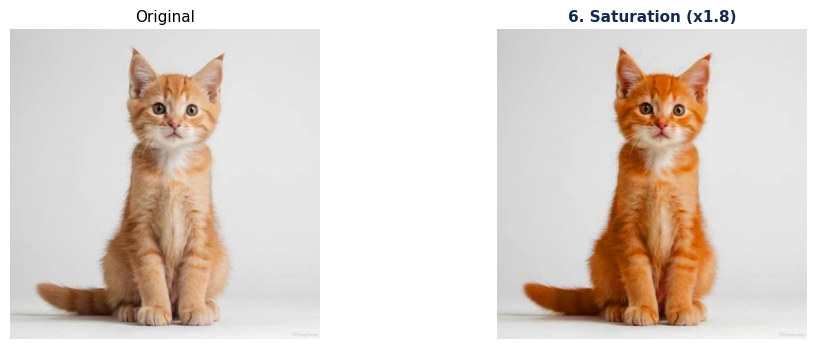

HSV = Hue (colour), Saturation (strength), Value (brightness).


In [13]:
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)   # RGB -> HSV; channel 1 is S (saturation)

# TODO 12: multiply the saturation channel by 1.8 and keep it inside 0..255
hsv[..., 1] = np.clip(hsv[...,1] * 1.8,0,255)  # TODO 12

aug_img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)     # back to RGB so we can display it
show_pair(aug_img, '6. Saturation (x1.8)', 'HSV = Hue (colour), Saturation (strength), Value (brightness).')

#### Family C. Noise and Blur

**7. Gaussian Noise**: Add small random values to every pixel, like a photo taken in low light.

**Look for:** a grainy texture over the whole image. Zoom in to see it clearly.

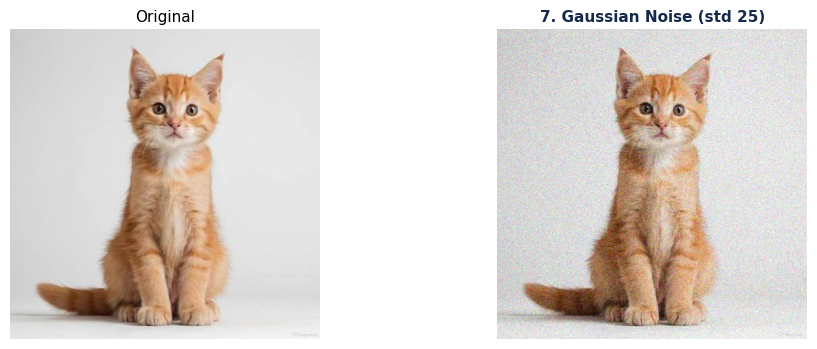

Every pixel received a different random value.


In [15]:
# TODO 13: create random noise with mean 0, standard deviation 25, and the same shape as img_rgb
# Hint: rng.normal(loc=..., scale=..., size=...)
noise = rng.normal(loc=0,scale=25,size=img_rgb.shape)  # TODO 13

aug_img = np.clip(img_rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)   # add the noise, keep inside 0..255
show_pair(aug_img, '7. Gaussian Noise (std 25)', 'Every pixel received a different random value.')

**8. Gaussian Blur**: Average each pixel with its neighbours, like a shaky or out-of-focus camera.

**Look for:** fine details such as text and thin lines disappear first.

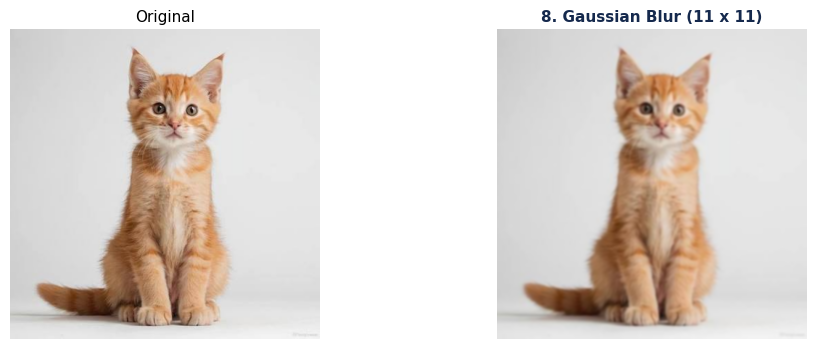

Same function we used before Canny, but much stronger.


In [16]:
# TODO 14: blur img_rgb strongly with an 11 x 11 Gaussian blur (you already used this function in Technique 2)
aug_img = cv2.GaussianBlur(img_rgb,(11,11),0) # TODO 14
show_pair(aug_img, '8. Gaussian Blur (11 x 11)', 'Same function we used before Canny, but much stronger.')

#### Family D. Occlusion

**9. Cutout**: Hide a random rectangle. The model must recognise the scene even when part of it is blocked.

**Look for:** a gray box hiding part of the scene. Its position is random but the same for everyone (fixed seed).

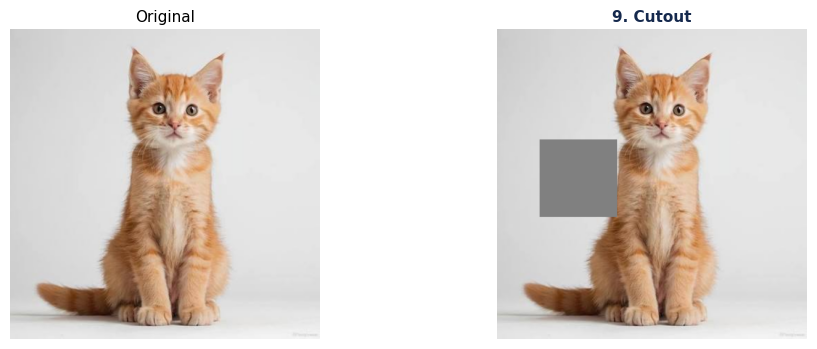

Hidden box at x=88, y=228, size 160 x 160.


In [17]:
aug_img = img_rgb.copy()                                  # copy, so the original image is not changed
bh, bw  = H // 4, W // 4                                  # box = 25% of height and width
y = int(rng.integers(0, H - bh)); x = int(rng.integers(0, W - bw))   # random top-left corner inside the image

# TODO 15: fill the box (rows y to y + bh, columns x to x + bw) with gray (value 128)
aug_img[y:y + bh, x:x + bw] = 128 # TODO 15
show_pair(aug_img, '9. Cutout', f'Hidden box at x={x}, y={y}, size {bw} x {bh}.')

#### All augmentations side by side

One original image became **9 new training images**. A model trained on all of them sees much more variety than a model trained on the original alone.

**What you will see:** the original and all 9 augmented versions in one grid.

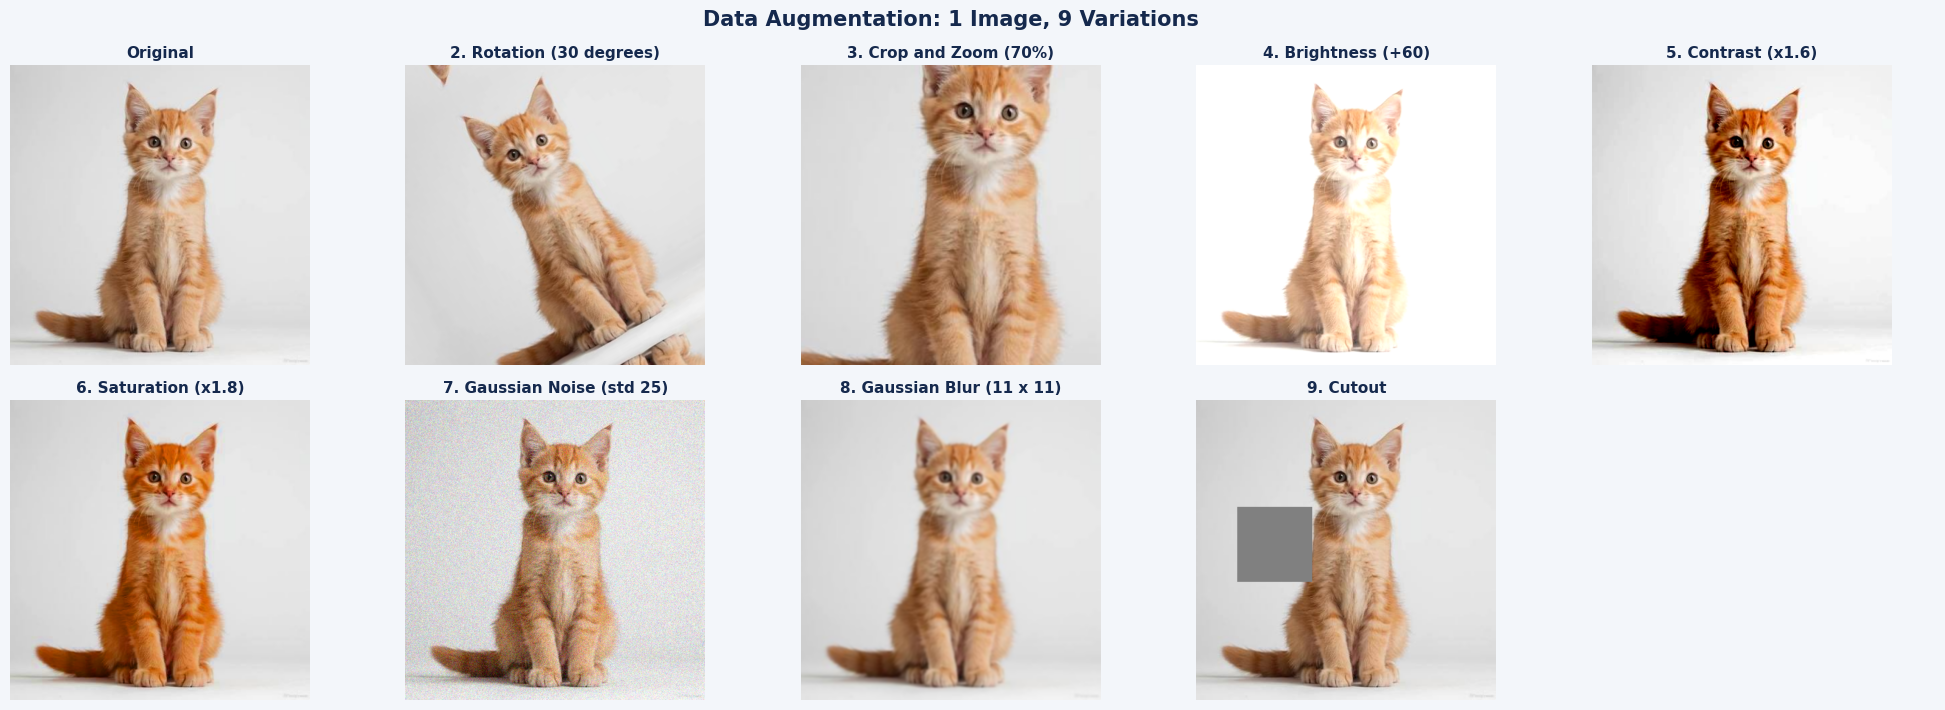

Techniques applied: 8 / 9


In [18]:
# List of (title, image): the original first, then the 9 saved augmentations
gallery = [('Original', img_rgb)] + list(augmented.items())

cols = 5                                                  # 5 images per row
rows = int(np.ceil(len(gallery) / cols))                  # rows needed: 10 images / 5 = 2
fig, axes = plt.subplots(rows, cols, figsize=(20, 3.6 * rows))
fig.patch.set_facecolor('#F3F6FA')                        # light background colour
for ax in axes.ravel():                                   # ravel() turns the 2D grid of plots into one list
    ax.axis('off')
for ax, (title, image) in zip(axes.ravel(), gallery):     # put each image in its own box
    ax.imshow(image)
    ax.set_title(title, fontsize=11, color='#15294D', fontweight='bold')
plt.suptitle('Data Augmentation: 1 Image, 9 Variations', fontsize=15, color='#15294D', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Techniques applied: {len(augmented)} / 9')         # less than 9 means a technique cell was skipped

#### How it is done in real training

Above, we chose fixed values so we could compare. In real training, a **random** combination is applied every time the model sees the image, so it never sees exactly the same picture twice. `torchvision.transforms` does this in a few lines. Run the cell more than once: you get different results every time.

**What you will see:** 8 different random versions of your image in a 2 x 4 grid, each one 224 x 224.

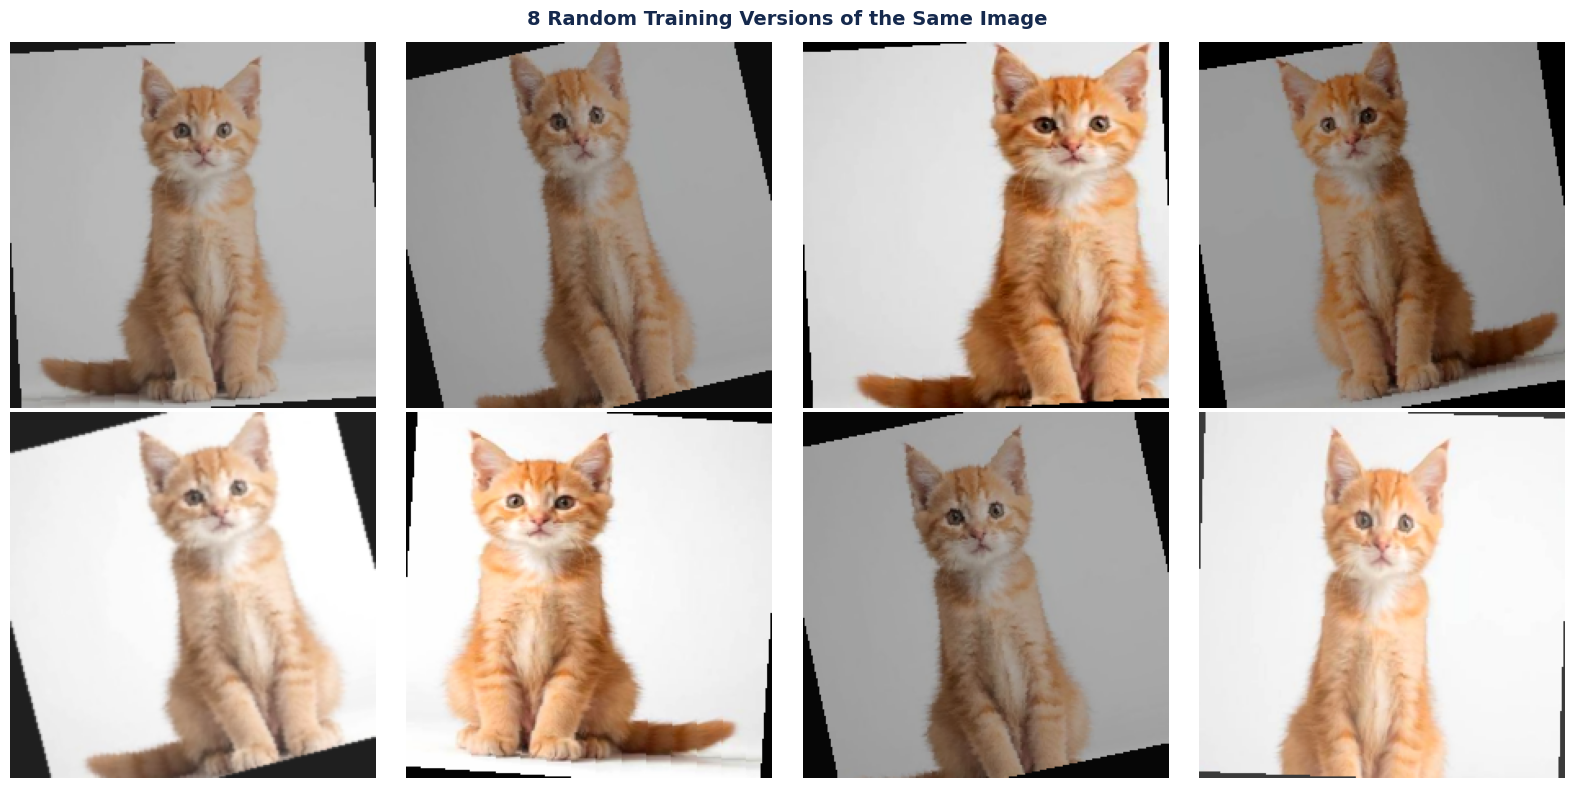

In [19]:
# A chain of random augmentations, applied in order every time an image passes through it
train_augment = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),               # A. crop and zoom: random crop of 60% to 100% of the image, resized to 224 x 224
    T.RandomHorizontalFlip(p=0.5),                            # A. flip (50% of the time)
    T.RandomRotation(degrees=15),                             # A. rotation: random angle between -15 and +15
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),  # B. photometric: random change of up to 40% each
    T.RandomApply([T.GaussianBlur(kernel_size=9)], p=0.3),    # C. blur (30% of the time)
])

pil_img = Image.fromarray(img_rgb)                            # torchvision transforms expect a PIL image, not a NumPy array
fig, axes = plt.subplots(2, 4, figsize=(16, 8))              # 2 rows x 4 columns = 8 images
for ax in axes.ravel():
    ax.imshow(train_augment(pil_img))                         # each call gives a NEW random version
    ax.axis('off')
plt.suptitle('8 Random Training Versions of the Same Image', fontsize=14, color='#15294D', fontweight='bold')
plt.tight_layout(); plt.show()

---
# PART 2: Preview of Tomorrow

<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Load Image &rarr; Grayscale &rarr; Edges &rarr; Preprocess &rarr; Augment &rarr; <b style='color:#6FAF22'>[ CNN Preview ]</b></div>

<div style="background:#EFF6FF;border-left:5px solid #0D9488;padding:14px 18px;border-radius:6px;margin-top:10px">
<b style="color:#0D9488">You do NOT need to understand this code yet.</b> Just run it and watch.<br><br>
<b>MobileNetV2</b> is a CNN already trained on about 1.2 million images (ImageNet, 1,000 everyday categories). It will look at your <b>original</b> image (not the augmented ones) and tell you its top 5 guesses.<br><br>
Notice that it does the same preprocessing you did in Technique 3: resize, crop to 224 x 224, scale, standardize.
</div>

**What the cell below does:** downloads MobileNetV2 (about 14 MB, first time only), prepares your image, and prints the top 5 guesses with their confidence.<br>**What you will see:** a table of 5 class names and percentages. The percentages of all 1,000 classes add up to 100%.

In [20]:
print('Loading MobileNetV2 (downloads about 14 MB the first time)...')

# 1) Load the pre-trained model
weights = models.MobileNet_V2_Weights.DEFAULT        # the learned numbers from training on ImageNet
model   = models.mobilenet_v2(weights=weights).eval()   # build the CNN with those weights; eval() = prediction mode (not training)
labels  = weights.meta['categories']                 # the 1,000 ImageNet class names

# 2) Prepare the image exactly the way the model was trained (same idea as Technique 3)
preprocess = T.Compose([
    T.Resize(256),                                   # shorter side -> 256
    T.CenterCrop(224),                               # 224 x 224 from the centre (no stretching)
    T.ToTensor(),                                    # 0..255 -> 0..1, shape (3, 224, 224)
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),   # standardize with the ImageNet mean and std
])

input_tensor = preprocess(Image.fromarray(img_rgb)).unsqueeze(0)   # add batch dim -> (1, 3, 224, 224); models expect a batch of images

# 3) Predict
with torch.no_grad():                                # no_grad: we only predict, no learning, so it is faster
    probs = torch.softmax(model(input_tensor)[0], dim=0)   # model gives 1,000 scores; softmax turns them into probabilities that add up to 1

# 4) Keep the 5 highest probabilities
top5_prob, top5_idx = torch.topk(probs, 5)           # values and positions of the top 5
labels_list = [labels[i] for i in top5_idx.tolist()] # position -> class name
probs_list  = [p * 100 for p in top5_prob.tolist()]  # 0..1 -> percentage

# 5) Print a small table (each # = 4%)
print('\n' + '=' * 55)
print(f'{"Rank":<6}{"What the CNN sees":<30}{"Confidence":>12}')
print('-' * 55)
for rank, (name, p) in enumerate(zip(labels_list, probs_list), start=1):
    print(f'#{rank:<5}{name:<30}{p:>10.1f}%  ' + '#' * int(p / 4))
print('=' * 55)

Loading MobileNetV2 (downloads about 14 MB the first time)...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 63.1MB/s]



Rank  What the CNN sees               Confidence
-------------------------------------------------------
#1    Egyptian cat                        13.9%  ###
#2    tabby                               10.8%  ##
#3    tiger cat                            9.4%  ##
#4    lynx                                 4.9%  #
#5    Persian cat                          1.8%  


**Same result as a chart.** This cell draws the top 5 guesses next to your image so you can compare them at a glance.

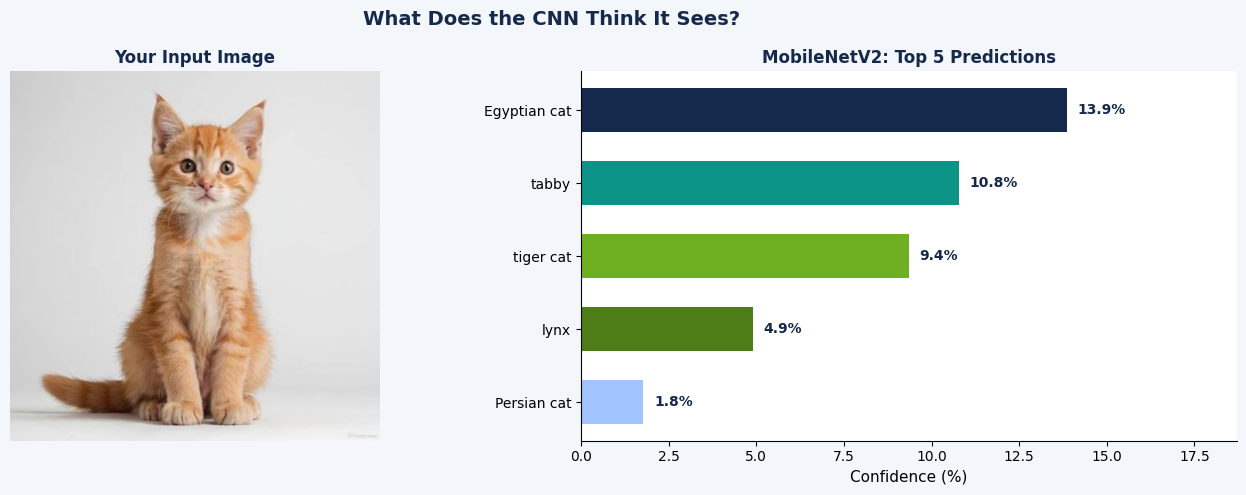

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))       # left: your image, right: bar chart
fig.patch.set_facecolor('#F3F6FA')

axes[0].imshow(img_rgb)
axes[0].set_title('Your Input Image', fontsize=12, color='#15294D', fontweight='bold')
axes[0].axis('off')

# Horizontal bars; [::-1] reverses the lists so the highest guess appears at the top
colors_bar = ['#15294D', '#0D9488', '#6FAF22', '#4E7D17', '#A0C4FF']
bars = axes[1].barh(labels_list[::-1], probs_list[::-1], color=colors_bar[::-1], height=0.6)
axes[1].set_xlabel('Confidence (%)', fontsize=11)
axes[1].set_title('MobileNetV2: Top 5 Predictions', fontsize=12, color='#15294D', fontweight='bold')
axes[1].set_xlim(0, max(probs_list) * 1.35)           # extra space on the right for the % labels
axes[1].spines[['top', 'right']].set_visible(False)   # remove the top and right border lines
for bar, p in zip(bars, probs_list[::-1]):            # write the % at the end of each bar
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{p:.1f}%', va='center', fontsize=10, color='#15294D', fontweight='bold')

plt.suptitle('What Does the CNN Think It Sees?', fontsize=14, color='#15294D', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Challenge (for fast finishers)

**Question:** does noise create fake edges?

1. Take the noisy image from technique 7: `augmented['7. Gaussian Noise (std 25)']`.
2. Convert it to grayscale and apply Canny with the same thresholds as Technique 2 (80, 180), **without** blurring first.
3. Print the number of edge pixels for the original image (`edges`) and for the noisy image.
4. Now blur the noisy grayscale image first (5 x 5) and run Canny again. What changed, and why?

In [22]:
# Your code here
noisy      = augmented['7. Gaussian Noise (std 25)']
noisy_gray = cv2.cvtColor(noisy, cv2.COLOR_RGB2GRAY)

edges_noisy   = cv2.Canny(noisy_gray, 80, 180)                                  # no blur
edges_blurred = cv2.Canny(cv2.GaussianBlur(noisy_gray, (5, 5), 0), 80, 180)     # blur first

print(f'Original (blurred before Canny) : {np.count_nonzero(edges):,} edge pixels')
print(f'Noisy, no blur                  : {np.count_nonzero(edges_noisy):,} edge pixels')
print(f'Noisy, blurred first            : {np.count_nonzero(edges_blurred):,} edge pixels')

Original (blurred before Canny) : 18,864 edge pixels
Noisy, no blur                  : 92,349 edge pixels
Noisy, blurred first            : 4,007 edge pixels


---
## Think About It

<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:14px 18px;border-radius:6px;margin:12px 0">

**Q1.** ImageNet has no category called "mosque in Makkah". What did the CNN guess instead, and why? What would change if we trained it on Saudi landmark images?

**Q2.** Look at the Canny result. The first layers of a CNN learn filters that respond to edges like these. Why would edges be a useful first step before recognising whole objects?

**Q3.** The CNN receives 3 x 224 x 224 = **150,528 numbers** for one prediction. How do you think it decides which numbers matter?

**Q4.** Why must we **not** apply augmentation to test images?

**Q5.** You are training a model to read handwritten Arabic letters. Which of the 9 augmentations would you remove, and why?

</div>

<div style="background:#15294D;padding:16px 20px;border-radius:8px;margin-top:16px;text-align:center">
<p style="color:#6FAF22;font-size:16px;font-weight:bold;margin:0">Tomorrow: Day 2</p>
<p style="color:white;margin:8px 0 4px 0;font-size:14px">You will learn exactly how MobileNetV2 makes these predictions.</p>
<p style="color:#A0C4FF;margin:0;font-size:13px">Object Detection | Bounding Boxes | YOLO | Transfer Learning</p>
</div>